In [28]:
# %load_ext autoreload
# %autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import skopi as sk

import torch
from tqdm import tqdm 
import time
import h5py

from neurorient import uniform_points_on_sphere
from neurorient.reconstruction.slicing import get_reciprocal_mesh, get_real_mesh
import scipy

import os, glob
os.environ["USE_CUPY"] = "1"
os.environ.get('USE_CUPY')

'1'

In [29]:
data_type = 'downsampled_reduced_128x128'

img_size = 128

In [30]:
data_path = "/pscratch/sd/z/zhantao/neurorient_repo/data_PR772"
save_dir = '/pscratch/sd/z/zhantao/neurorient_repo/data/PR772'

In [31]:
h5_file_list = sorted(glob.glob(os.path.join(data_path, "*.h5")))
print(*h5_file_list, sep='\n')

/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_182_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_183_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_184_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_185_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_186_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_188_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_190_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_191_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_192_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_193_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_194_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/amo86615_196_PR772_single.h5
/pscratch/sd/z/zhantao/neurorient_repo/data_PR772/am

In [32]:
photons = []

for _h5_file in tqdm(h5_file_list):
    with h5py.File(_h5_file, "r") as f:
        _photons = f['photonConverter/pnccdBack/photonCount'][:]
        photons.append(_photons)
        
images = np.concatenate(photons, axis=0)[:,1:-2,:]

100%|██████████| 13/13 [00:13<00:00,  1.01s/it]


In [33]:
print(images.shape)

(14772, 257, 257)


In [34]:
det = np.loadtxt('input/dragonfly/det_pnccd_back.dat', skiprows=1)
det_shape = (260, 257)

In [35]:
pixel_position_reciprocal = 1e7 * det[:,:3].reshape((1,)+det_shape+(3,))
pixel_position_reciprocal = pixel_position_reciprocal[:,1:-2,:,:]

In [36]:
img_real_mesh = get_real_mesh(min(det_shape), pixel_position_reciprocal.max())
_mesh = get_reciprocal_mesh(min(det_shape), pixel_position_reciprocal.max())
vol_real_mesh = get_real_mesh(_mesh.shape[0], _mesh.max())

In [37]:
idx_xx, idx_yy = np.meshgrid(np.arange(img_size), np.arange(img_size))

In [38]:
pixel_index_map = np.concatenate([idx_xx[None,...,None], idx_yy[None,...,None]], axis=-1)

In [39]:
zoom_ratio = img_size / min(det_shape)

images_downsampled = np.zeros((images.shape[0], img_size, img_size))

In [40]:
for i in tqdm(range(images.shape[0])):
    img = images[i]
    img_downsampled = scipy.ndimage.zoom(img, zoom_ratio, order=1)
    images_downsampled[i] = img_downsampled

100%|██████████| 14772/14772 [00:07<00:00, 1919.53it/s]


In [41]:
import numpy as np
from sklearn.decomposition import PCA

B = images_downsampled.shape[0]

images_for_filter = scipy.ndimage.zoom(images_downsampled, (1, 1/4, 1/4), order=1)
images_for_filter /= images_for_filter.mean(axis=(-2,-1))[:,None,None]
# Flatten the dataset
images_flattened = images_for_filter.reshape(B, -1)

# Initialize PCA, you can choose the number of components based on variance you want to preserve
pca = PCA(n_components=2)  # for example, retain 50 components
images_pca = pca.fit_transform(images_flattened)





In [42]:
from sklearn.cluster import KMeans

# Assuming you want a certain number of clusters, which can depend on B_final
num_clusters = 10  # Example, adjust based on your requirement
kmeans = KMeans(n_clusters=num_clusters, random_state=42)
labels = kmeans.fit_predict(images_pca)


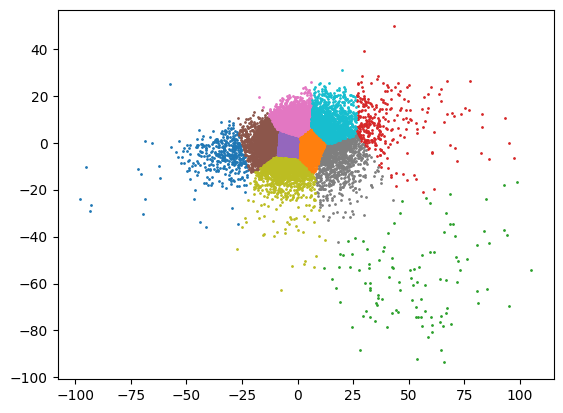

In [43]:
for i in range(num_clusters):
    plt.scatter(images_pca[labels==i,0], images_pca[labels==i,1], s=1)

In [48]:
B_final = 8000  # The final number of images you want
samples_per_cluster = B_final // num_clusters

final_images_indices = []

for i in range(num_clusters):
    # Find indices of all images in this cluster
    indices = np.where(labels == i)[0]
    print(f"# of samples for cluster {i}: {len(indices)}")
    # If there are not enough images in the cluster, take all samples
    if len(indices) < samples_per_cluster:
        sampled_indices = indices
    else:
        sampled_indices = np.random.choice(indices, size=samples_per_cluster, replace=False)
    
    final_images_indices.extend(sampled_indices)

final_images_indices = np.array(final_images_indices)
final_images = images_downsampled[final_images_indices]


# of samples for cluster 0: 396
# of samples for cluster 1: 2492
# of samples for cluster 2: 107
# of samples for cluster 3: 305
# of samples for cluster 4: 2778
# of samples for cluster 5: 1888
# of samples for cluster 6: 2666
# of samples for cluster 7: 876
# of samples for cluster 8: 1618
# of samples for cluster 9: 1646


In [49]:
final_images_indices.shape

(6408,)

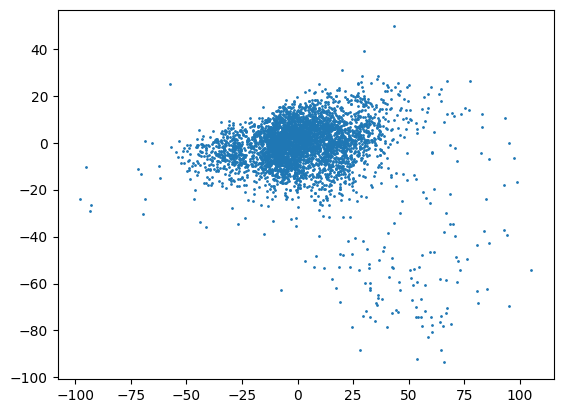

In [22]:
plt.scatter(images_pca[final_images_indices,0], images_pca[final_images_indices,1], s=1)

In [42]:
pixel_position_reciprocal_downsampled = scipy.ndimage.zoom(pixel_position_reciprocal, (1, zoom_ratio, zoom_ratio, 1), order=1)

img_real_mesh_downsampled = get_real_mesh(img_size, pixel_position_reciprocal_downsampled.max())
_mesh_downsampled = get_reciprocal_mesh(img_size, pixel_position_reciprocal_downsampled.max())
vol_real_mesh_downsampled = get_real_mesh(_mesh_downsampled.shape[0], _mesh_downsampled.max())

In [43]:
pt_fpath = os.path.join(save_dir, f'PR772_neurorient_{data_type}.pt')
torch.save(
    {
        'orientations': None,
        'intensities': torch.from_numpy(final_images.astype('float')).float(),
        'pixel_position_reciprocal': torch.from_numpy(pixel_position_reciprocal_downsampled).float(),
        'pixel_index_map': torch.from_numpy(pixel_index_map).long(),
        'volume': None,
        'img_real_mesh': img_real_mesh_downsampled.float(),
        'vol_real_mesh': vol_real_mesh_downsampled.float(),
        'time_stamp': time.strftime("%Y%m%d-%H%M")
    }, pt_fpath
)
print("data wrote to: \n", pt_fpath)

data wrote to: 
 /pscratch/sd/z/zhantao/neurorient_repo/data/PR772/PR772_neurorient_downsampled_reduced_128x128.pt


In [44]:
pixel_distance_reciprocal = np.linalg.norm(pixel_position_reciprocal_downsampled, axis=-1)

In [45]:
h5_fpath = os.path.join(
    save_dir, 
    f'PR772_neurorient_{data_type}.h5')
with h5py.File(h5_fpath, 'w') as f:
    f.create_dataset('intensities', data=final_images[:, None])
    f.create_dataset('orientations', data=np.zeros((final_images.shape[0], 4)))
    f.create_dataset('pixel_position_reciprocal', data=pixel_position_reciprocal_downsampled)
    f.create_dataset('pixel_distance_reciprocal', data=pixel_distance_reciprocal)
    f.create_dataset('pixel_index_map', data=pixel_index_map)
print("data wrote to: \n", h5_fpath)

data wrote to: 
 /pscratch/sd/z/zhantao/neurorient_repo/data/PR772/PR772_neurorient_downsampled_reduced_128x128.h5


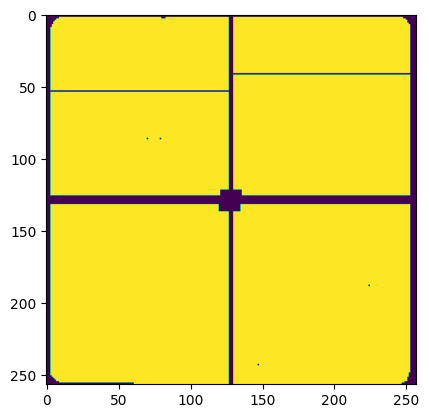

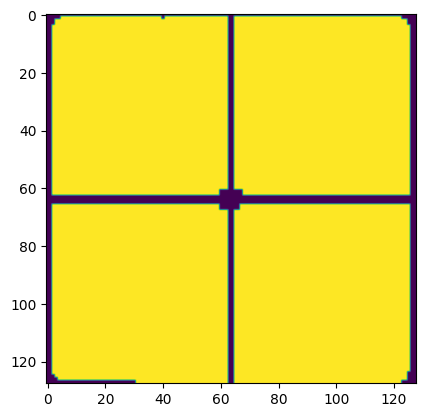

In [68]:
_beam_stop_mask = det[:,-1].reshape(det_shape)[1:-2,:]
beam_stop_mask = torch.zeros(_beam_stop_mask.shape)
beam_stop_mask[_beam_stop_mask!=2] = 1
plt.imshow(beam_stop_mask)

beam_stop_mask_downsampled = scipy.ndimage.zoom(beam_stop_mask, zoom_ratio, order=1)
beam_stop_mask_downsampled[beam_stop_mask_downsampled>=0.5] = 1
beam_stop_mask_downsampled[beam_stop_mask_downsampled<0.5] = 0
plt.figure()
plt.imshow(beam_stop_mask_downsampled)
torch.save({'mask': torch.from_numpy(beam_stop_mask_downsampled).float()}, f'input/PR772/beam_stop_mask_{data_type}.pt')